<a href="https://colab.research.google.com/github/RickV777/GorilaGym/blob/master/YouTube_TFT_Objetivo1_Preprocesamiento.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ANALISIS DE LOS FACTORES DETERMINANTES DEL ENGAGEMENT EN YOUTUBE
## Aplicacion de Estadistica Inferencial y Analisis Factorial sobre un Dataset Publico en Kaggle
**Universidad de Guayaquil - Facultad de Ciencias Matematicas y Fisicas - Carrera de Software**

---

## OBJETIVO 1 - Recoleccion, Organizacion y Preprocesamiento del Dataset
> Recolectar el dataset publico YouTube Trending Video Dataset disponible en Kaggle para su correcta
> organizacion y preprocesamiento, garantizando la calidad, consistencia e integridad de los datos.

**Paises seleccionados:** Estados Unidos (US) + Mexico (MX)  
**Dataset:** YouTube Trending Video Dataset (updated daily) - Kaggle (rsrishav, v1345)  
**Periodo:** Agosto 2020 - Abril 2024


---
## SECCION 1 - Instalacion e Importacion de Librerias

In [ ]:
# Instalacion de librerias necesarias
!pip install kaggle factor_analyzer missingno --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 kB 2.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from IPython.display import display

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')
sns.set_palette('Set2')

print('Librerias importadas correctamente')
print(f'  pandas  : {pd.__version__}')
print(f'  numpy   : {np.__version__}')
print(f'  seaborn : {sns.__version__}')

Librerias importadas correctamente
  pandas  : 2.2.2
  numpy   : 2.0.2
  seaborn : 0.13.2


---
## SECCION 2 - Descarga del Dataset desde Kaggle

> **Instrucciones para configurar Kaggle API:**
> 1. Inicia sesion en kaggle.com
> 2. Ve a tu perfil -> Settings -> API -> Create New Token
> 3. Se descarga un archivo kaggle.json - subelo a Colab con la celda de abajo


In [6]:
# REEMPLAZA la Sección 2 completa por esto:
from google.colab import files
import os

DATA_DIR = '/content/data'
os.makedirs(DATA_DIR, exist_ok=True)

print('Sube los 4 archivos descargados de Kaggle:')
print('  - US_youtube_trending_data.csv')
print('  - MX_youtube_trending_data.csv')
print('  - US_category_id.json')
print('  - MX_category_id.json')

uploaded = files.upload()

for filename, content in uploaded.items():
    with open(f'{DATA_DIR}/{filename}', 'wb') as f:
        f.write(content)
    print(f'Guardado: {filename}')

Sube los 4 archivos descargados de Kaggle:
  - US_youtube_trending_data.csv
  - MX_youtube_trending_data.csv
  - US_category_id.json
  - MX_category_id.json


Saving MX_category_id.json to MX_category_id.json
Saving MX_youtube_trending_data.csv to MX_youtube_trending_data.csv
Saving US_category_id.json to US_category_id.json
Saving US_youtube_trending_data.csv to US_youtube_trending_data.csv
Guardado: MX_category_id.json
Guardado: MX_youtube_trending_data.csv
Guardado: US_category_id.json
Guardado: US_youtube_trending_data.csv


In [8]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from IPython.display import display

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')
sns.set_palette('Set2')

DATA_DIR = '/content/data'

print('Listo')

Listo


---
## SECCION 3 - Carga y Exploracion Inicial de los Datos

In [9]:
df_us = pd.read_csv(f'{DATA_DIR}/US_youtube_trending_data.csv')
df_mx = pd.read_csv(f'{DATA_DIR}/MX_youtube_trending_data.csv')

df_us['country'] = 'US'
df_mx['country'] = 'MX'

print('DIMENSIONES DE LOS DATASETS')
print(f'  US -> {df_us.shape[0]:,} filas x {df_us.shape[1]} columnas')
print(f'  MX -> {df_mx.shape[0]:,} filas x {df_mx.shape[1]} columnas')
print(f'\n  Total combinado -> {df_us.shape[0] + df_mx.shape[0]:,} registros')

DIMENSIONES DE LOS DATASETS
  US -> 268,587 filas x 17 columnas
  MX -> 268,398 filas x 17 columnas

  Total combinado -> 536,985 registros


In [10]:
print('Primeras filas - US:')
display(df_us.head(3))
print('\nPrimeras filas - MX:')
display(df_mx.head(3))

Primeras filas - US:


,video_id,title,publishedAt,channelId,channelTitle,categoryId,trending_date,tags,view_count,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,description,country
0,3C66w5Z0ixs,I ASKED HER TO BE MY GIRLFRIEND...,2020-08-11T19:20:14Z,UCvtRTOMP2TqYqu51xNrqAzg,Brawadis,22,2020-08-12T00:00:00Z,brawadis|prank|basketball|skits|ghost|funny vi...,1514614,156908,5855,35313,https://i.ytimg.com/vi/3C66w5Z0ixs/default.jpg,False,False,SUBSCRIBE to BRAWADIS ▶ http://bit.ly/Subscrib...,US
1,M9Pmf9AB4Mo,Apex Legends | Stories from the Outlands – “Th...,2020-08-11T17:00:10Z,UC0ZV6M2THA81QT9hrVWJG3A,Apex Legends,20,2020-08-12T00:00:00Z,Apex Legends|Apex Legends characters|new Apex ...,2381688,146739,2794,16549,https://i.ytimg.com/vi/M9Pmf9AB4Mo/default.jpg,False,False,"While running her own modding shop, Ramya Pare...",US
2,J78aPJ3VyNs,I left youtube for a month and THIS is what ha...,2020-08-11T16:34:06Z,UCYzPXprvl5Y-Sf0g4vX-m6g,jacksepticeye,24,2020-08-12T00:00:00Z,jacksepticeye|funny|funny meme|memes|jacksepti...,2038853,353787,2628,40221,https://i.ytimg.com/vi/J78aPJ3VyNs/default.jpg,False,False,I left youtube for a month and this is what ha...,US



Primeras filas - MX:


,video_id,title,publishedAt,channelId,channelTitle,categoryId,trending_date,tags,view_count,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,description,country
0,SsWHMAhshPQ,Ovi x Natanael Cano x Aleman x Big Soto - Veng...,2020-08-11T23:00:10Z,UC648rgJOboZlgcDbW00vTSA,Rancho Humilde,10,2020-08-12T00:00:00Z,Vengo De Nada|Aleman|Ovi|Big Soto|Trap|Ovi Nat...,741028,113999,4380,5620,https://i.ytimg.com/vi/SsWHMAhshPQ/default.jpg,False,False,Vengo De Nada - Ovi x Natanael Cano x Aleman x...,MX
1,JOaeND0xUNk,Belinda y Christian Nodal cantan De los besos ...,2020-08-11T18:03:06Z,UCNVrBkfp4_TG9x4h5kvLeAQ,TV Azteca,24,2020-08-12T00:00:00Z,tv azteca|videos de tv azteca|azteca uno|en su...,402507,8102,831,803,https://i.ytimg.com/vi/JOaeND0xUNk/default.jpg,False,False,Encendieron el escenario de La Voz. TV AztecaT...,MX
2,SV91jnGs--s,¿QUIÉN HACE LOS MEJORES NUGGETS? | EL GUZII,2020-08-11T19:57:02Z,UCuGn3ioftOo6jvHE1YK4Bfw,El Guzii,26,2020-08-12T00:00:00Z,El Guzii|Guzzi|Guzy|Guzii Style|Recetas Divert...,735044,62188,1053,4100,https://i.ytimg.com/vi/SV91jnGs--s/default.jpg,False,False,Si tienes 10 kg de sobre peso tal vez te haz p...,MX


In [11]:
print('Tipos de datos - US:')
print(df_us.dtypes)

Tipos de datos - US:
video_id             object
title                object
publishedAt          object
channelId            object
channelTitle         object
categoryId            int64
trending_date        object
tags                 object
view_count            int64
likes                 int64
dislikes              int64
comment_count         int64
thumbnail_link       object
comments_disabled      bool
ratings_disabled       bool
description          object
country              object
dtype: object


---
## SECCION 4 - Carga de Categorias (JSON) y Mapeo

In [ ]:
def parse_categories(json_path):
    with open(json_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    return {
        int(item['id']): item['snippet']['title']
        for item in data['items']
        if item.get('snippet', {}).get('assignable', False)
    }

cat_us = parse_categories(f'{DATA_DIR}/US_category_id.json')
cat_mx = parse_categories(f'{DATA_DIR}/MX_category_id.json')
cat_map = {**cat_us, **cat_mx}

print(f'Categorias cargadas: {len(cat_map)} unicas')
for k, v in sorted(cat_map.items()):
    print(f'  {k:3d} -> {v}')

In [ ]:
df_us['category_name'] = df_us['categoryId'].map(cat_map)
df_mx['category_name'] = df_mx['categoryId'].map(cat_map)
print('Categorias mapeadas correctamente')

---
## SECCION 5 - Combinacion de Datasets US + MX

In [12]:
df = pd.concat([df_us, df_mx], ignore_index=True)
print(f'Dataset combinado: {df.shape[0]:,} filas x {df.shape[1]} columnas')
print('\nDistribucion por pais:')
print(df['country'].value_counts())

Dataset combinado: 536,985 filas x 17 columnas

Distribucion por pais:
country
US    268587
MX    268398
Name: count, dtype: int64


---
## SECCION 6 - Limpieza y Calidad de Datos
### 6.1 - Analisis de Valores Nulos

REPORTE DE VALORES NULOS:


,Columna,Nulos,Porcentaje (%)
15,description,15050,2.8000


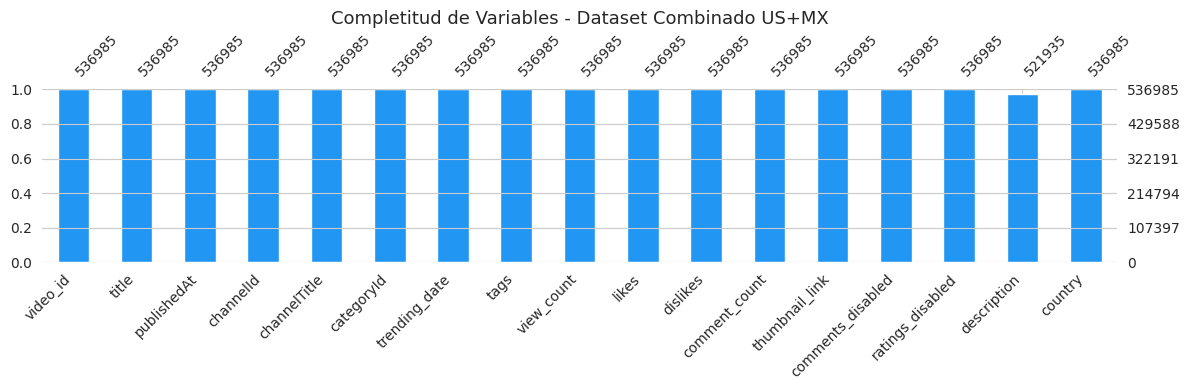

In [13]:
nulos = pd.DataFrame({
    'Columna': df.columns,
    'Nulos': df.isnull().sum().values,
    'Porcentaje (%)': (df.isnull().sum().values / len(df) * 100).round(2)
}).sort_values('Nulos', ascending=False)

print('REPORTE DE VALORES NULOS:')
display(nulos[nulos['Nulos'] > 0])

fig, ax = plt.subplots(figsize=(12, 4))
msno.bar(df, ax=ax, color='#2196F3', fontsize=10)
ax.set_title('Completitud de Variables - Dataset Combinado US+MX', fontsize=13)
plt.tight_layout()
plt.savefig('/content/fig_01_valores_nulos.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
# Recuperar category_name si se saltó la Sección 4
import json

def parse_categories(json_path):
    with open(json_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    return {
        int(item['id']): item['snippet']['title']
        for item in data['items']
        if item.get('snippet', {}).get('assignable', False)
    }

cat_us = parse_categories(f'{DATA_DIR}/US_category_id.json')
cat_mx = parse_categories(f'{DATA_DIR}/MX_category_id.json')
cat_map = {**cat_us, **cat_mx}

df_us['category_name'] = df_us['categoryId'].map(cat_map)
df_mx['category_name'] = df_mx['categoryId'].map(cat_map)

# Combinar si no se hizo la Sección 5
df = pd.concat([df_us, df_mx], ignore_index=True)

print(f'Listo - df tiene {len(df):,} filas')
print(f'category_name presente: {"category_name" in df.columns}')

Listo - df tiene 536,985 filas
category_name presente: True


In [16]:
df['description'] = df['description'].fillna('')
df['tags'] = df['tags'].fillna('[none]')

antes = len(df)
df = df.dropna(subset=['category_name'])
print(f'Filas eliminadas por category_name nula: {antes - len(df):,}')
print(f'Nulos restantes: {df.isnull().sum().sum()}')

Filas eliminadas por category_name nula: 0
Nulos restantes: 0


### 6.2 - Eliminacion de Duplicados

In [17]:
# Un mismo video puede aparecer varios dias en trending.
# Duplicado real = mismo video_id + mismo trending_date + mismo pais
antes = len(df)
df = df.drop_duplicates(subset=['video_id', 'trending_date', 'country'])
print(f'Duplicados eliminados: {antes - len(df):,}')
print(f'Registros restantes : {len(df):,}')

Duplicados eliminados: 8,196
Registros restantes : 528,789


### 6.3 - Conversion de Tipos de Datos

In [18]:
df['publishedAt'] = pd.to_datetime(df['publishedAt'], utc=True)
df['trending_date'] = pd.to_datetime(df['trending_date'], utc=True)

numericas = ['view_count', 'likes', 'comment_count']
for col in numericas:
    df[col] = pd.to_numeric(df[col], errors='coerce')

antes = len(df)
df = df[(df['view_count'] > 0) & (df['likes'] >= 0) & (df['comment_count'] >= 0)]
print(f'Filas con valores invalidos eliminadas: {antes - len(df):,}')
print(f'Registros restantes: {len(df):,}')
print('\nEstadisticas descriptivas basicas:')
display(df[numericas].describe())

Filas con valores invalidos eliminadas: 126
Registros restantes: 528,663

Estadisticas descriptivas basicas:


,view_count,likes,comment_count
count,528663.0000,528663.0000,528663.0000
mean,2572217.3846,134374.4965,9748.6642
std,8741835.1280,434301.6625,72634.2828
min,2658.0000,0.0000,0.0000
25%,423462.5000,16577.0000,933.0000
50%,877662.0000,40409.0000,2223.0000
75%,2053132.0000,104612.0000,5640.0000
max,1407643634.0000,16165348.0000,6798264.0000


### 6.4 - Deteccion y Tratamiento de Outliers

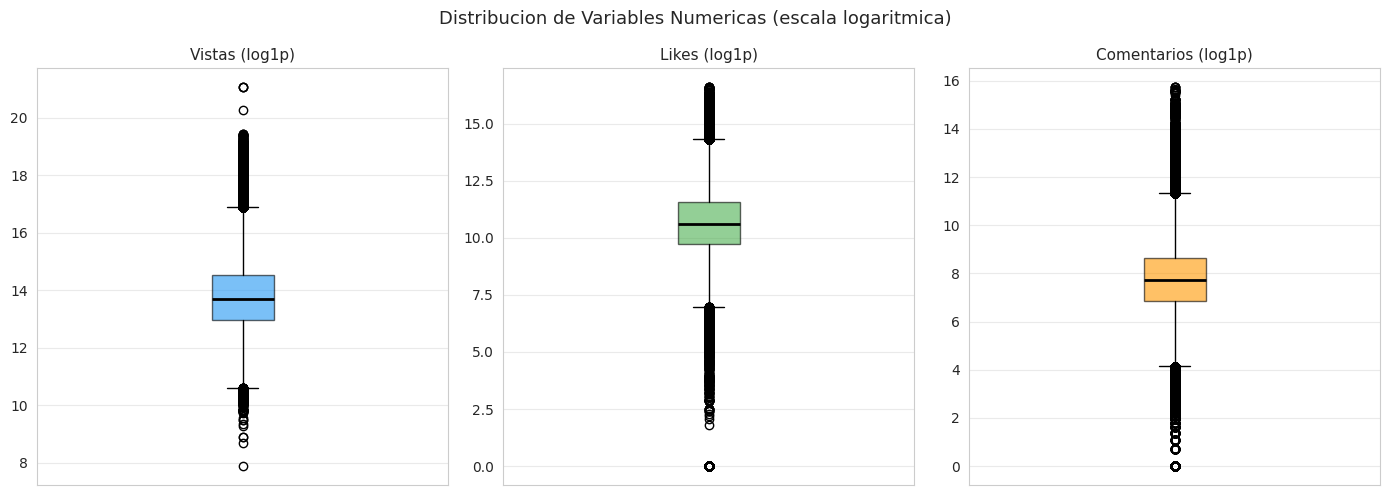

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
colores = ['#2196F3', '#4CAF50', '#FF9800']
etiquetas = ['Vistas', 'Likes', 'Comentarios']

for ax, col, color, label in zip(axes, numericas, colores, etiquetas):
    data = np.log1p(df[col])
    ax.boxplot(data, patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.6),
               medianprops=dict(color='black', linewidth=2))
    ax.set_title(f'{label} (log1p)', fontsize=11)
    ax.set_xticks([])
    ax.grid(axis='y', alpha=0.4)

fig.suptitle('Distribucion de Variables Numericas (escala logaritmica)', fontsize=13)
plt.tight_layout()
plt.savefig('/content/fig_02_outliers_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
def iqr_bounds(serie, factor=3.0):
    Q1, Q3 = serie.quantile(0.25), serie.quantile(0.75)
    IQR = Q3 - Q1
    return Q1 - factor * IQR, Q3 + factor * IQR

print('ANALISIS DE OUTLIERS EXTREMOS (factor IQR = 3.0):')
for col in numericas:
    lb, ub = iqr_bounds(df[col])
    n_outliers = ((df[col] < lb) | (df[col] > ub)).sum()
    pct = n_outliers / len(df) * 100
    print(f'  {col:15s} -> {n_outliers:6,} outliers ({pct:.2f}%)')

print('\nDECISION: Se conservan outliers. Son videos virales legitimos.')
print('Se aplicara transformacion log1p en modelos de regresion.')

ANALISIS DE OUTLIERS EXTREMOS (factor IQR = 3.0):
  view_count      -> 33,371 outliers (6.31%)
  likes           -> 36,389 outliers (6.88%)
  comment_count   -> 39,688 outliers (7.51%)

DECISION: Se conservan outliers. Son videos virales legitimos.
Se aplicara transformacion log1p en modelos de regresion.


---
## SECCION 7 - Ingenieria de Variables (Feature Engineering)

In [21]:
# 7.1 - Variable dependiente: Engagement Rate
# Formula: (likes + comment_count) / view_count
df['engagement_rate'] = (df['likes'] + df['comment_count']) / df['view_count']
df = df[df['engagement_rate'].between(0, 1, inclusive='both')]

print('Variable dependiente creada: engagement_rate')
print(f'  Media   : {df["engagement_rate"].mean():.4f}')
print(f'  Mediana : {df["engagement_rate"].median():.4f}')
print(f'  Std Dev : {df["engagement_rate"].std():.4f}')

Variable dependiente creada: engagement_rate
  Media   : 0.0613
  Mediana : 0.0531
  Std Dev : 0.0450


In [22]:
# 7.2 - Variables temporales
df['publish_hour']      = df['publishedAt'].dt.hour
df['publish_dayofweek'] = df['publishedAt'].dt.dayofweek
df['publish_month']     = df['publishedAt'].dt.month
df['publish_year']      = df['publishedAt'].dt.year

def franja_horaria(hour):
    if 6 <= hour < 12:    return 'Manana (6-12h)'
    elif 12 <= hour < 18: return 'Tarde (12-18h)'
    elif 18 <= hour < 24: return 'Noche (18-24h)'
    else:                  return 'Madrugada (0-6h)'

df['franja_horaria'] = df['publish_hour'].apply(franja_horaria)

dias = {0:'Lunes', 1:'Martes', 2:'Miercoles', 3:'Jueves',
        4:'Viernes', 5:'Sabado', 6:'Domingo'}
df['publish_dayname'] = df['publish_dayofweek'].map(dias)

print('Variables temporales creadas correctamente')

Variables temporales creadas correctamente


In [23]:
# 7.3 - Numero de tags
def contar_tags(tags_str):
    if tags_str == '[none]' or pd.isna(tags_str):
        return 0
    return len(tags_str.split('|'))

df['num_tags'] = df['tags'].apply(contar_tags)

df['rango_tags'] = pd.cut(
    df['num_tags'],
    bins=[-1, 0, 10, 20, 30, 100],
    labels=['Sin tags', '1-10', '11-20', '21-30', '30+']
)
print('Variable creada: num_tags')
print(df['rango_tags'].value_counts().sort_index())

Variable creada: num_tags
rango_tags
Sin tags         0
1-10        203232
11-20       131019
21-30       125770
30+          68642
Name: count, dtype: int64


In [24]:
# 7.4 - Estado de comentarios y valoraciones
df['comments_disabled'] = df['comments_disabled'].astype(bool)
df['ratings_disabled']  = df['ratings_disabled'].astype(bool)
print('Variables booleanas convertidas')

Variables booleanas convertidas


In [25]:
# 7.5 - Longitud del titulo
df['title_length'] = df['title'].str.len()
df['rango_titulo'] = pd.cut(
    df['title_length'],
    bins=[0, 30, 60, 90, 200],
    labels=['Corto (0-30)', 'Medio (31-60)', 'Largo (61-90)', 'Muy largo (90+)']
)
print(f'Variable creada: title_length - Media: {df["title_length"].mean():.1f} caracteres')

Variable creada: title_length - Media: 53.2 caracteres


In [26]:
# 7.6 - Dias hasta trending
df['dias_hasta_trending'] = (
    df['trending_date'] - df['publishedAt']
).dt.total_seconds() / 86400
df['dias_hasta_trending'] = df['dias_hasta_trending'].clip(lower=0, upper=365)
print(f'Variable creada: dias_hasta_trending - Media: {df["dias_hasta_trending"].mean():.1f} dias')

Variable creada: dias_hasta_trending - Media: 4.4 dias


In [27]:
# 7.7 - Transformaciones logaritmicas
df['log_views']      = np.log1p(df['view_count'])
df['log_likes']      = np.log1p(df['likes'])
df['log_comments']   = np.log1p(df['comment_count'])
df['log_engagement'] = np.log1p(df['engagement_rate'])
print('Variables logaritmicas creadas: log_views, log_likes, log_comments, log_engagement')

Variables logaritmicas creadas: log_views, log_likes, log_comments, log_engagement


---
## SECCION 8 - Analisis Exploratorio de Datos (EDA)

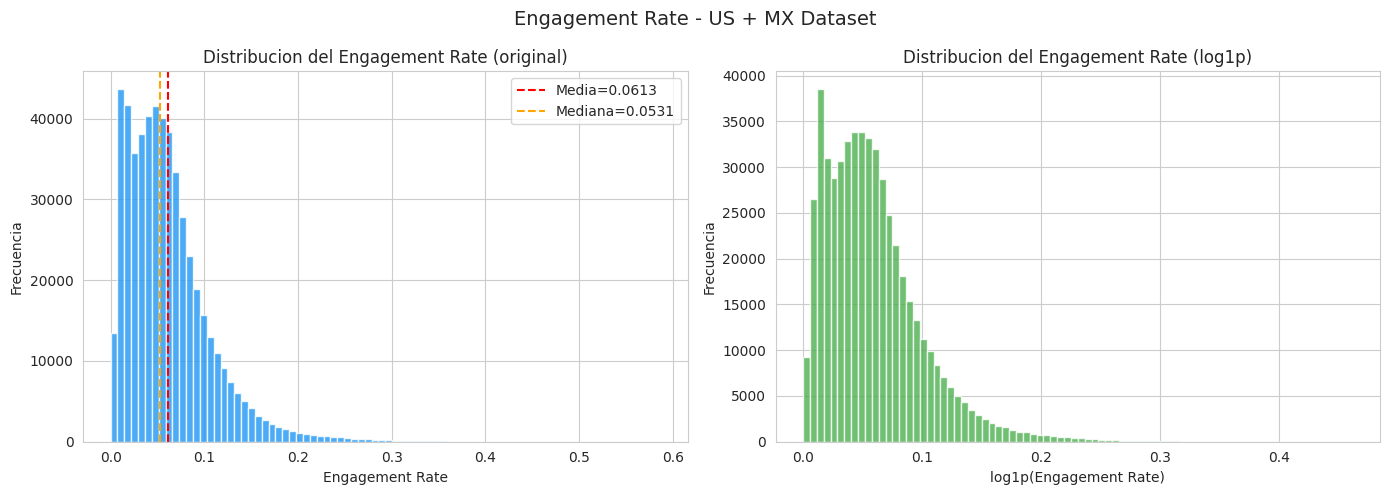

In [28]:
# 8.1 - Distribucion del Engagement Rate
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['engagement_rate'], bins=80, color='#2196F3', edgecolor='white', alpha=0.8)
axes[0].set_title('Distribucion del Engagement Rate (original)', fontsize=12)
axes[0].set_xlabel('Engagement Rate')
axes[0].set_ylabel('Frecuencia')
axes[0].axvline(df['engagement_rate'].mean(), color='red', linestyle='--',
                label=f'Media={df["engagement_rate"].mean():.4f}')
axes[0].axvline(df['engagement_rate'].median(), color='orange', linestyle='--',
                label=f'Mediana={df["engagement_rate"].median():.4f}')
axes[0].legend()

axes[1].hist(df['log_engagement'], bins=80, color='#4CAF50', edgecolor='white', alpha=0.8)
axes[1].set_title('Distribucion del Engagement Rate (log1p)', fontsize=12)
axes[1].set_xlabel('log1p(Engagement Rate)')
axes[1].set_ylabel('Frecuencia')

fig.suptitle('Engagement Rate - US + MX Dataset', fontsize=14)
plt.tight_layout()
plt.savefig('/content/fig_03_engagement_distribucion.png', dpi=150, bbox_inches='tight')
plt.show()

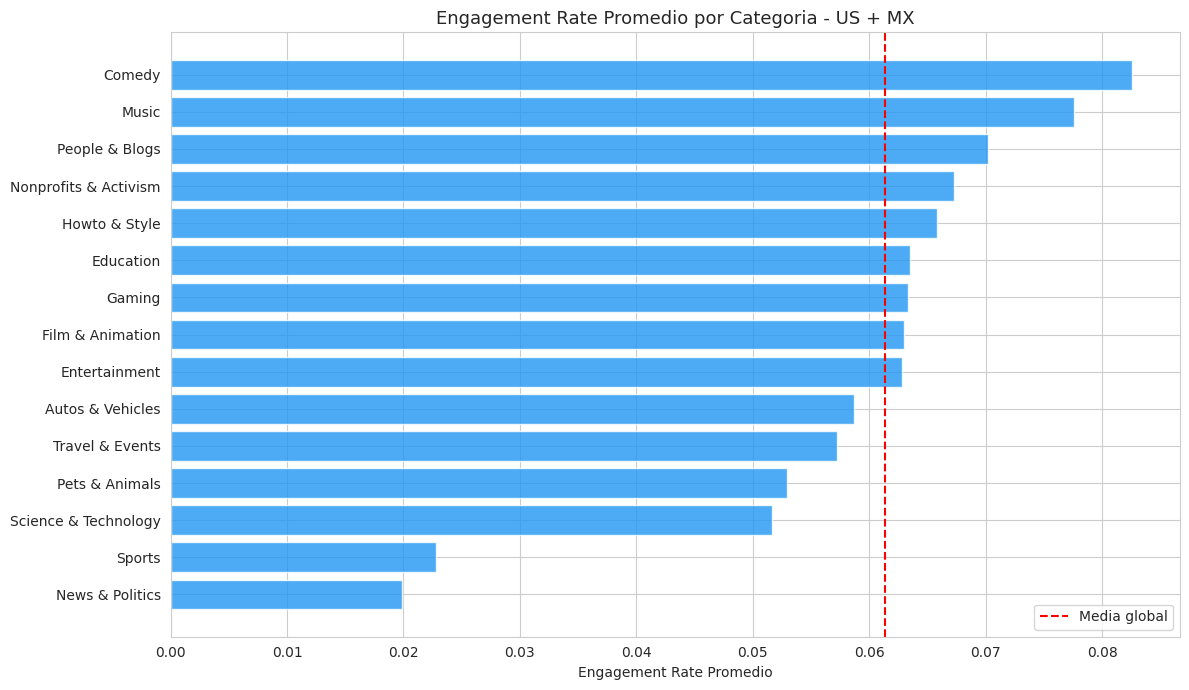

In [29]:
# 8.2 - Engagement por categoria
eng_cat = (df.groupby('category_name')['engagement_rate']
             .agg(['mean','median','count'])
             .sort_values('mean', ascending=True)
             .reset_index())

fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(eng_cat['category_name'], eng_cat['mean'], color='#2196F3', alpha=0.8)
ax.axvline(df['engagement_rate'].mean(), color='red', linestyle='--', linewidth=1.5, label='Media global')
ax.set_title('Engagement Rate Promedio por Categoria - US + MX', fontsize=13)
ax.set_xlabel('Engagement Rate Promedio')
ax.legend()
plt.tight_layout()
plt.savefig('/content/fig_04_engagement_categoria.png', dpi=150, bbox_inches='tight')
plt.show()

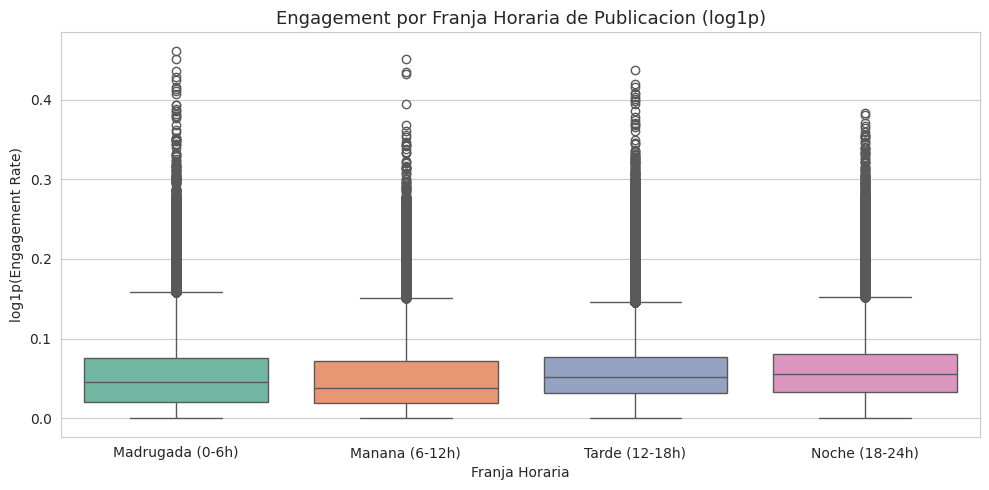

In [30]:
# 8.3 - Engagement por franja horaria
order_franjas = ['Madrugada (0-6h)', 'Manana (6-12h)', 'Tarde (12-18h)', 'Noche (18-24h)']

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df, x='franja_horaria', y='log_engagement',
            order=order_franjas, palette='Set2', ax=ax)
ax.set_title('Engagement por Franja Horaria de Publicacion (log1p)', fontsize=13)
ax.set_xlabel('Franja Horaria')
ax.set_ylabel('log1p(Engagement Rate)')
plt.tight_layout()
plt.savefig('/content/fig_05_engagement_franja.png', dpi=150, bbox_inches='tight')
plt.show()

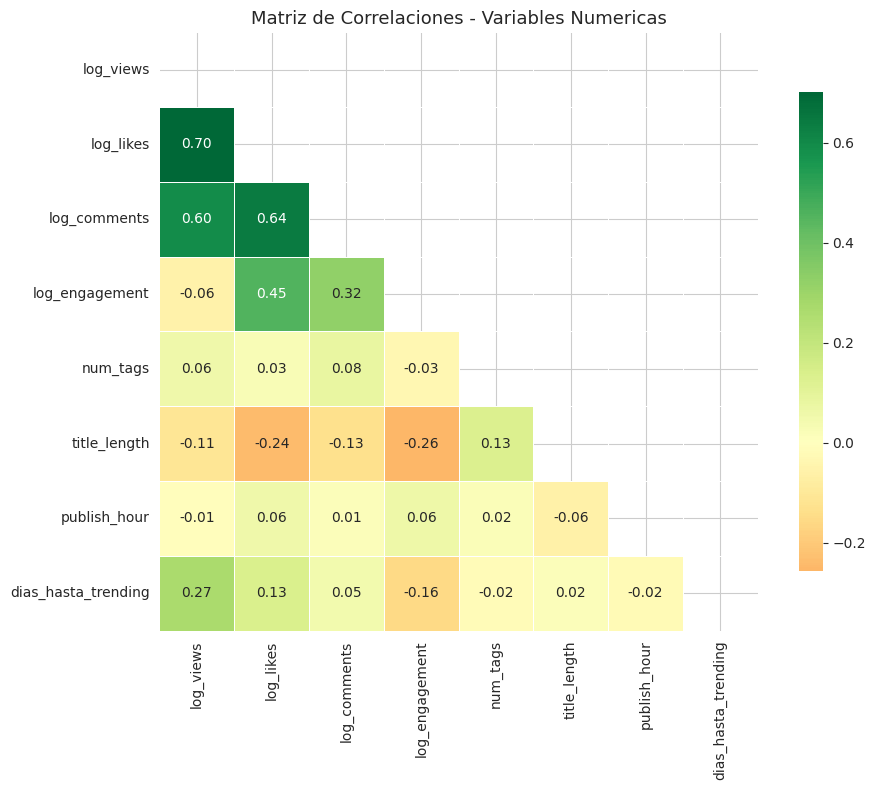

In [31]:
# 8.4 - Mapa de calor de correlaciones
vars_corr = ['log_views', 'log_likes', 'log_comments', 'log_engagement',
             'num_tags', 'title_length', 'publish_hour', 'dias_hasta_trending']

corr_matrix = df[vars_corr].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, square=True,
            linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Matriz de Correlaciones - Variables Numericas', fontsize=13)
plt.tight_layout()
plt.savefig('/content/fig_06_correlaciones.png', dpi=150, bbox_inches='tight')
plt.show()

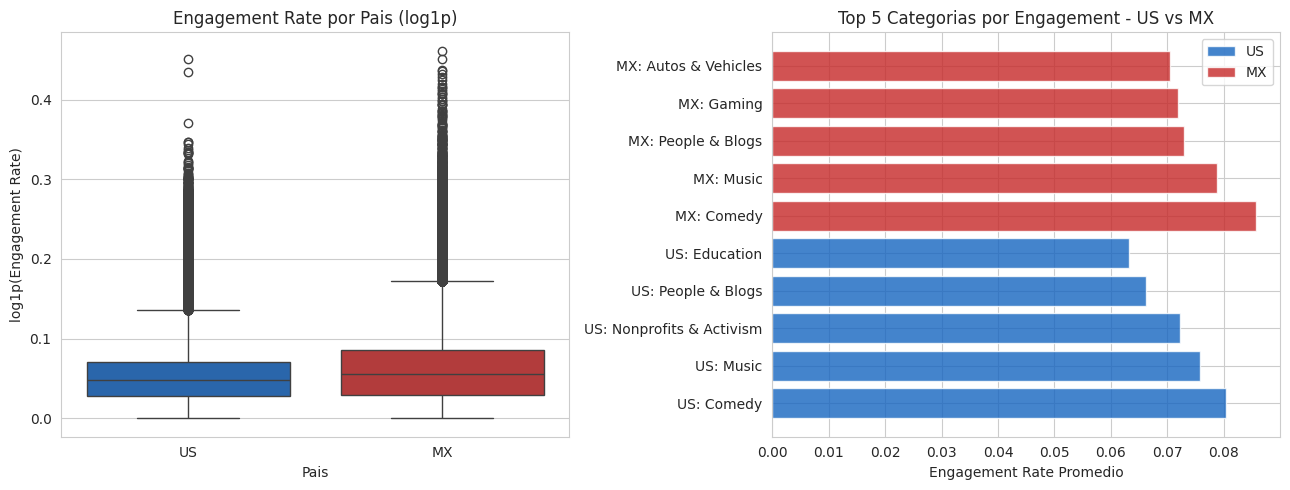

In [32]:
# 8.5 - Comparacion US vs MX
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=df, x='country', y='log_engagement', palette=['#1565C0','#C62828'], ax=axes[0])
axes[0].set_title('Engagement Rate por Pais (log1p)', fontsize=12)
axes[0].set_xlabel('Pais')
axes[0].set_ylabel('log1p(Engagement Rate)')

top_cat = (df.groupby(['country','category_name'])['engagement_rate']
             .mean().reset_index()
             .sort_values(['country','engagement_rate'], ascending=[True, False])
             .groupby('country').head(5))

for pais, color in zip(['US','MX'], ['#1565C0','#C62828']):
    data_pais = top_cat[top_cat['country'] == pais]
    axes[1].barh(
        [f'{pais}: {c}' for c in data_pais['category_name']],
        data_pais['engagement_rate'],
        color=color, alpha=0.8, label=pais
    )

axes[1].set_title('Top 5 Categorias por Engagement - US vs MX', fontsize=12)
axes[1].set_xlabel('Engagement Rate Promedio')
axes[1].legend()
plt.tight_layout()
plt.savefig('/content/fig_07_us_vs_mx.png', dpi=150, bbox_inches='tight')
plt.show()

---
## SECCION 9 - Exportacion del Dataset Procesado

In [33]:
columnas_finales = [
    'video_id', 'country',
    'publishedAt', 'trending_date',
    'publish_hour', 'publish_dayofweek', 'publish_dayname',
    'publish_month', 'publish_year', 'franja_horaria',
    'dias_hasta_trending',
    'category_name', 'title_length', 'num_tags', 'rango_tags', 'rango_titulo',
    'comments_disabled', 'ratings_disabled',
    'view_count', 'likes', 'comment_count',
    'log_views', 'log_likes', 'log_comments',
    'engagement_rate', 'log_engagement'
]

df_final = df[columnas_finales].copy()
print(f'Dataset final: {df_final.shape[0]:,} filas x {df_final.shape[1]} columnas')
display(df_final.head(3))

Dataset final: 528,663 filas x 26 columnas


,video_id,country,publishedAt,trending_date,publish_hour,publish_dayofweek,publish_dayname,publish_month,publish_year,franja_horaria,dias_hasta_trending,category_name,title_length,num_tags,rango_tags,rango_titulo,comments_disabled,ratings_disabled,view_count,likes,comment_count,log_views,log_likes,log_comments,engagement_rate,log_engagement
0,3C66w5Z0ixs,US,2020-08-11 19:20:14+00:00,2020-08-12 00:00:00+00:00,19,1,Martes,8,2020,Noche (18-24h),0.1943,People & Blogs,34,15,11-20,Medio (31-60),False,False,1514614,156908,35313,14.2307,11.9634,10.4720,0.1269,0.1195
1,M9Pmf9AB4Mo,US,2020-08-11 17:00:10+00:00,2020-08-12 00:00:00+00:00,17,1,Martes,8,2020,Tarde (12-18h),0.2916,Gaming,60,25,21-30,Medio (31-60),False,False,2381688,146739,16549,14.6833,11.8964,9.7141,0.0686,0.0663
2,J78aPJ3VyNs,US,2020-08-11 16:34:06+00:00,2020-08-12 00:00:00+00:00,16,1,Martes,8,2020,Tarde (12-18h),0.3097,Entertainment,53,30,21-30,Medio (31-60),False,False,2038853,353787,40221,14.5279,12.7765,10.6022,0.1932,0.1767


In [34]:
OUTPUT_PATH = '/content/youtube_dataset_procesado.csv'
df_final.to_csv(OUTPUT_PATH, index=False, encoding='utf-8-sig')

size_mb = os.path.getsize(OUTPUT_PATH) / (1024**2)
print(f'Dataset exportado: youtube_dataset_procesado.csv ({size_mb:.1f} MB)')

# Opcional: guardar en Google Drive
# from google.colab import drive
# drive.mount('/content/drive')
# df_final.to_csv('/content/drive/MyDrive/TFT_YouTube/youtube_dataset_procesado.csv', index=False)
# print('Tambien guardado en Google Drive')

Dataset exportado: youtube_dataset_procesado.csv (141.9 MB)


---
## SECCION 10 - Reporte Final de Preprocesamiento

In [35]:
print('=' * 60)
print('  REPORTE DE PREPROCESAMIENTO - OBJETIVO 1')
print('  YouTube Trending Video Dataset - US + MX')
print('=' * 60)
print(f'\nDATOS')
print(f'  Paises          : US (Estados Unidos), MX (Mexico)')
print(f'  Periodo         : {df_final["trending_date"].min().date()} -> {df_final["trending_date"].max().date()}')
print(f'  Registros total : {len(df_final):,}')
print(f'  Variables       : {df_final.shape[1]}')
print(f'  Registros US    : {(df_final["country"]=="US").sum():,}')
print(f'  Registros MX    : {(df_final["country"]=="MX").sum():,}')
print(f'\nLIMPIEZA')
print(f'  Duplicados eliminados    : OK')
print(f'  Nulos tratados           : OK')
print(f'  Valores negativos        : OK')
print(f'  Fechas convertidas       : OK')
print(f'\nVARIABLE DEPENDIENTE')
print(f'  engagement_rate = (likes + comments) / views')
print(f'  Media    : {df_final["engagement_rate"].mean():.4f}')
print(f'  Mediana  : {df_final["engagement_rate"].median():.4f}')
print(f'  Std Dev  : {df_final["engagement_rate"].std():.4f}')
print('\n' + '=' * 60)
print('  OBJETIVO 1 COMPLETADO')
print('  Proximo paso: Objetivo 2 - Pruebas de Hipotesis')
print('=' * 60)

  REPORTE DE PREPROCESAMIENTO - OBJETIVO 1
  YouTube Trending Video Dataset - US + MX

DATOS
  Paises          : US (Estados Unidos), MX (Mexico)
  Periodo         : 2020-08-12 -> 2024-04-14
  Registros total : 528,663
  Variables       : 26
  Registros US    : 264,439
  Registros MX    : 264,224

LIMPIEZA
  Duplicados eliminados    : OK
  Nulos tratados           : OK
  Valores negativos        : OK
  Fechas convertidas       : OK

VARIABLE DEPENDIENTE
  engagement_rate = (likes + comments) / views
  Media    : 0.0613
  Mediana  : 0.0531
  Std Dev  : 0.0450

  OBJETIVO 1 COMPLETADO
  Proximo paso: Objetivo 2 - Pruebas de Hipotesis


---
## Proximo Notebook: Objetivo 2 - Pruebas de Hipotesis

Con el dataset limpio y preprocesado, el siguiente paso es:
- **t-test / Mann-Whitney U**: Comparar engagement entre paises (US vs MX)
- **ANOVA / Kruskal-Wallis**: Diferencias de engagement entre categorias
- **ANOVA / Kruskal-Wallis**: Diferencias de engagement entre franjas horarias
- **Chi-cuadrado**: Relacion entre categoria y estado de comentarios/valoraciones

> El archivo `youtube_dataset_procesado.csv` sera la entrada del Objetivo 2.


In [36]:
from google.colab import drive
drive.mount('/content/drive')

import shutil
shutil.copy(
    '/content/youtube_dataset_procesado.csv',
    '/content/drive/MyDrive/youtube_dataset_procesado.csv'
)
print('Guardado en Google Drive')

Mounted at /content/drive
Guardado en Google Drive
